In [1]:
# ============================================================
# CORTEX-MH | Task 1 — Domain Gate / OOD Classifier
# ============================================================
# Inputs : Raw text
# Outputs: accept_reject, domain_confidence, rejection_reason
# Model  : TF-IDF (word + char n-gram) + Logistic Regression
# Data   : ourafla/Mental-Health_Text-Classification_Dataset (in-domain)
#          Salesforce/wikitext wikitext-103-v1 (OOD)
# ============================================================

# ── STEP 1: Setup ────────────────────────────────────────────
import os, json, pickle, re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42
    LANGDETECT_AVAILABLE = True
except ImportError:
    print("langdetect not found — installing...")
    os.system("pip install langdetect -q")
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42
    LANGDETECT_AVAILABLE = True

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = Path('/content/drive/MyDrive/CORTEX/T1')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")

langdetect not found — installing...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save dir: /content/drive/MyDrive/CORTEX/T1


In [2]:
# ── STEP 2: Load In-Domain Data (ourafla) ────────────────────
import pandas as pd

BASE_URL = ("https://huggingface.co/datasets/ourafla/"
            "Mental-Health_Text-Classification_Dataset/resolve/main/")

file_map = {
    "train":    "mental_heath_unbanlanced.csv",
    "test":     "mental_health_combined_test.csv",
    "features": "mental_health_feature_engineered.csv"
}

def find_text_column(df):
    candidates = ['text', 'post', 'statement', 'content', 'message', 'body']
    for c in candidates:
        if c in df.columns:
            return c
    str_cols = df.select_dtypes(include='object').columns
    avg_lens = {c: df[c].dropna().str.len().mean() for c in str_cols}
    return max(avg_lens, key=avg_lens.get)

texts_in = []
for split_name, fname in file_map.items():
    try:
        df = pd.read_csv(BASE_URL + fname)
        text_col = find_text_column(df)
        texts = df[text_col].dropna().astype(str).tolist()
        texts_in.extend(texts)
        print(f"  ✓ {split_name:8s} | {len(df):>6,} rows | text col: '{text_col}'")
    except Exception as e:
        print(f"  ✗ {split_name:8s} | FAILED: {e}")

# Deduplicate across files
before_dedup = len(texts_in)
texts_in = list(dict.fromkeys(texts_in))   # preserves order, removes exact dupes
print(f"\nTotal in-domain texts : {before_dedup:,}")
print(f"After deduplication   : {len(texts_in):,} "
      f"({before_dedup - len(texts_in):,} dupes removed)")
print(f"\nSample:\n  '{texts_in[0][:200]}'")

  ✓ train    | 49,612 rows | text col: 'text'
  ✓ test     |    992 rows | text col: 'text'
  ✓ features | 49,612 rows | text col: 'text'

Total in-domain texts : 100,216
After deduplication   : 49,441 (50,775 dupes removed)

Sample:
  'oh my gosh'


In [3]:
# ── STEP 3: Load OOD Data (go_emotions — hard negatives) ─────
# Google's go_emotions: ~58k Reddit comments labeled with 28 emotions.
# These are general Reddit posts that share emotional/MH-adjacent vocabulary
# (sadness, grief, nervousness, fear) without being crisis MH text.
# This is a much harder OOD test than WikiText-103.

from datasets import load_dataset
import numpy as np

print("Loading go_emotions dataset...")
go_emo = load_dataset("google-research-datasets/go_emotions", "simplified")
print(go_emo)

# Pool all splits
go_texts = []
for split_name in go_emo:
    df_go = go_emo[split_name].to_pandas()
    go_texts.extend(df_go['text'].dropna().astype(str).tolist())
    print(f"  Split '{split_name}': {len(df_go):,} rows")

print(f"\nTotal go_emotions texts: {len(go_texts):,}")

# ── Deduplicate ───────────────────────────────────────────────
before = len(go_texts)
go_texts = list(dict.fromkeys(go_texts))
print(f"After deduplication: {len(go_texts):,} ({before - len(go_texts):,} dupes removed)")

# ── Balance OOD to match in-domain size ──────────────────────
n_in = len(texts_in)
np.random.seed(42)

if len(go_texts) >= n_in:
    ood_texts = list(np.random.choice(go_texts, size=n_in, replace=False))
    print(f"OOD downsampled to match in-domain: {len(ood_texts):,}")
else:
    # go_emotions is smaller than in-domain — use all of it
    # and note the imbalance (handled by class_weight='balanced' in LR)
    ood_texts = go_texts
    print(f"WARNING: go_emotions ({len(ood_texts):,}) < in-domain ({n_in:,}).")
    print("Class imbalance will be handled by class_weight='balanced' in the LR.")

print(f"\nFinal OOD size : {len(ood_texts):,}")
print(f"Final in-domain: {n_in:,}")
print(f"\nSample OOD texts:")
for t in np.random.choice(ood_texts, size=3, replace=False):
    print(f"  '{t[:120]}'")



# # ── STEP 3: Load OOD Data (WikiText-103) ─────────────────────
# print("Loading WikiText-103...")
# wiki_raw = load_dataset("Salesforce/wikitext", "wikitext-103-v1")
# print(wiki_raw)

# def extract_wiki_paragraphs(dataset_split, min_words=15, max_words=250):
#     """
#     Extract clean paragraphs from WikiText.
#     Skips: section headers (= Title =), empty lines, very short/long text.
#     """
#     texts = []
#     for item in dataset_split:
#         t = item['text'].strip()
#         if not t:
#             continue
#         if t.startswith(' =') and t.endswith('= '):   # WikiText header format
#             continue
#         if len(t.split()) < min_words or len(t.split()) > max_words:
#             continue
#         texts.append(t)
#     return texts

# wiki_texts = extract_wiki_paragraphs(wiki_raw['train'])
# wiki_texts += extract_wiki_paragraphs(wiki_raw['validation'])
# print(f"WikiText paragraphs extracted: {len(wiki_texts)}")

# # Balance OOD to match in-domain size
# n_in = len(texts_in)
# np.random.seed(42)
# if len(wiki_texts) > n_in:
#     wiki_texts = list(np.random.choice(wiki_texts, size=n_in, replace=False))
# else:
#     print(f"WARNING: Only {len(wiki_texts)} OOD samples vs {n_in} in-domain.")

# print(f"OOD samples after balancing: {len(wiki_texts)}")

Loading go_emotions dataset...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
  Split 'train': 43,410 rows
  Split 'validation': 5,426 rows
  Split 'test': 5,427 rows

Total go_emotions texts: 54,263
After deduplication: 53,994 (269 dupes removed)
OOD downsampled to match in-domain: 49,441

Final OOD size : 49,441
Final in-domain: 49,441

Sample OOD texts:
  'I wish I could buy them I am here in Florida gets harder each day to find them'
  'Refrigerators? That's cool'
  'You have no idea how incredible they make me feel in every single way. It's not something I'm used to!!'


In [4]:
# ── STEP 4: Text Sanitization Rules ──────────────────────────

def compute_repetition_ratio(text):
    """Fraction of text dominated by a single character."""
    chars = [c for c in text.lower() if c.isalpha()]
    if not chars:
        return 1.0
    most_common_count = Counter(chars).most_common(1)[0][1]
    return most_common_count / len(chars)

def is_url_only(text):
    cleaned = re.sub(r'https?://\S+', '', text).strip()
    return len(cleaned) < 10

def is_symbol_only(text):
    alpha_count = sum(c.isalpha() for c in text)
    return alpha_count < 5

def sanitize_text(text, min_words=5, max_rep=0.45):
    """
    Rule-based pre-filter.
    Returns rejection_reason (str) or None (passes to model).
    """
    if not isinstance(text, str) or not text.strip():
        return 'invalid'

    text = text.strip()

    if is_url_only(text):
        return 'url_only'

    if is_symbol_only(text):
        return 'symbol_only'

    words = text.split()
    if len(words) < min_words:
        return 'too_short'

    if compute_repetition_ratio(text) > max_rep:
        return 'high_repetition'

    try:
        lang = detect(text)
        if lang != 'en':
            return 'non_english'
    except Exception:
        return 'non_english'

    return None  # passes all rule checks


# Apply to both splits
print("Applying sanitization rules...")

in_clean, in_rejected = [], []
for t in texts_in:
    reason = sanitize_text(t)
    (in_clean if reason is None else in_rejected).append((t, reason))

ood_clean, ood_rejected = [], []
for t in ood_texts:                          # ← updated from wiki_texts
    reason = sanitize_text(t)
    (ood_clean if reason is None else ood_rejected).append((t, reason))

in_clean_texts  = [t for t, _ in in_clean]
ood_clean_texts = [t for t, _ in ood_clean]

print(f"\nIn-domain : {len(in_clean_texts):,} clean | {len(in_rejected):,} rejected by rules")
print(f"OOD       : {len(ood_clean_texts):,} clean | {len(ood_rejected):,} rejected by rules")

in_rej_counts  = Counter(r for _, r in in_rejected)
ood_rej_counts = Counter(r for _, r in ood_rejected)
print(f"\nIn-domain rejection reasons : {dict(in_rej_counts)}")
print(f"OOD rejection reasons       : {dict(ood_rej_counts)}")






# # ── STEP 4: Text Sanitization Rules ──────────────────────────

# def compute_repetition_ratio(text):
#     """Fraction of text dominated by a single character."""
#     chars = [c for c in text.lower() if c.isalpha()]
#     if not chars:
#         return 1.0
#     most_common_count = Counter(chars).most_common(1)[0][1]
#     return most_common_count / len(chars)

# def is_url_only(text):
#     cleaned = re.sub(r'https?://\S+', '', text).strip()
#     return len(cleaned) < 10

# def is_symbol_only(text):
#     """True if text has almost no alphabetic content."""
#     alpha_count = sum(c.isalpha() for c in text)
#     return alpha_count < 5

# def sanitize_text(text, min_words=5, max_rep=0.45):
#     """
#     Rule-based pre-filter.
#     Returns rejection_reason (str) or None (passes to model).
#     """
#     if not isinstance(text, str) or not text.strip():
#         return 'invalid'

#     text = text.strip()

#     if is_url_only(text):
#         return 'url_only'

#     if is_symbol_only(text):
#         return 'symbol_only'

#     words = text.split()
#     if len(words) < min_words:
#         return 'too_short'

#     if compute_repetition_ratio(text) > max_rep:
#         return 'high_repetition'

#     try:
#         lang = detect(text)
#         if lang != 'en':
#             return 'non_english'
#     except Exception:
#         return 'non_english'

#     return None  # passes all rule checks


# # Apply to both splits
# print("Applying sanitization rules...")

# in_clean, in_rejected = [], []
# for t in texts_in:
#     reason = sanitize_text(t)
#     (in_clean if reason is None else in_rejected).append((t, reason))

# ood_clean, ood_rejected = [], []
# for t in wiki_texts:
#     reason = sanitize_text(t)
#     (ood_clean if reason is None else ood_rejected).append((t, reason))

# in_clean_texts  = [t for t, _ in in_clean]
# ood_clean_texts = [t for t, _ in ood_clean]

# print(f"\nIn-domain : {len(in_clean_texts):,} clean | {len(in_rejected):,} rejected by rules")
# print(f"OOD       : {len(ood_clean_texts):,} clean | {len(ood_rejected):,} rejected by rules")

# # Rejection breakdown
# in_rej_counts  = Counter(r for _, r in in_rejected)
# ood_rej_counts = Counter(r for _, r in ood_rejected)
# print(f"\nIn-domain rejection reasons : {dict(in_rej_counts)}")
# print(f"OOD rejection reasons       : {dict(ood_rej_counts)}")

Applying sanitization rules...

In-domain : 45,455 clean | 3,986 rejected by rules
OOD       : 42,572 clean | 6,869 rejected by rules

In-domain rejection reasons : {'too_short': 2489, 'non_english': 1444, 'symbol_only': 23, 'high_repetition': 26, 'url_only': 4}
OOD rejection reasons       : {'non_english': 1059, 'too_short': 5462, 'url_only': 330, 'high_repetition': 8, 'symbol_only': 10}


In [5]:
# ── STEP 5: Dataset Preparation ──────────────────────────────
texts  = in_clean_texts + ood_clean_texts
labels = [1] * len(in_clean_texts) + [0] * len(ood_clean_texts)
# 1 = in-domain (accept), 0 = OOD (reject)

print(f"Combined dataset: {len(texts):,} samples")
print(f"  In-domain: {sum(labels):,} ({sum(labels)/len(labels)*100:.1f}%)")
print(f"  OOD:       {len(labels)-sum(labels):,} ({(len(labels)-sum(labels))/len(labels)*100:.1f}%)")

# Stratified 70 / 15 / 15 split
X_tv, X_test, y_tv, y_test = train_test_split(
    texts, labels, test_size=0.15, random_state=42, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15/0.85, random_state=42, stratify=y_tv
)

print(f"\nSplit  | Samples | In-domain | OOD")
print(f"Train  | {len(X_train):,}   | {sum(y_train):,}     | {len(y_train)-sum(y_train):,}")
print(f"Val    | {len(X_val):,}   | {sum(y_val):,}     | {len(y_val)-sum(y_val):,}")
print(f"Test   | {len(X_test):,}   | {sum(y_test):,}     | {len(y_test)-sum(y_test):,}")

Combined dataset: 88,027 samples
  In-domain: 45,455 (51.6%)
  OOD:       42,572 (48.4%)

Split  | Samples | In-domain | OOD
Train  | 61,618   | 31,818     | 29,800
Val    | 13,204   | 6,818     | 6,386
Test   | 13,205   | 6,819     | 6,386


In [6]:
# ── STEP 6: DistilBERT Setup + Tokenization ──────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

MODEL_NAME  = 'distilbert-base-uncased'
MAX_LENGTH  = 128
BATCH_SIZE  = 32
EPOCHS      = 4
LR          = 2e-5

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class DomainDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

print("Tokenizing splits...")
train_dataset = DomainDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = DomainDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = DomainDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# ── Model ─────────────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# Class weights — handle imbalance if go_emotions < in-domain
n_ood = len([l for l in y_train if l == 0])
n_in  = len([l for l in y_train if l == 1])
w_ood = len(y_train) / (2 * n_ood)
w_in  = len(y_train) / (2 * n_in)
class_weights = torch.tensor([w_ood, w_in], dtype=torch.float).to(DEVICE)
print(f"\nClass weights — OOD: {w_ood:.3f} | In-domain: {w_in:.3f}")

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"\nModel loaded | Total training steps: {total_steps}")




# # ── STEP 6: TF-IDF + Logistic Regression ─────────────────────
# # Combined feature space:
# #   word 1-2 gram: catches domain vocabulary (suicidal ideation, anxiety attack)
# #   char 3-5 gram: catches morphology (depress*, anxiet*, suicid*, hopeless*)

# word_tfidf = TfidfVectorizer(
#     analyzer='word',
#     ngram_range=(1, 2),
#     max_features=40_000,
#     sublinear_tf=True,
#     min_df=2,
#     strip_accents='unicode',
#     decode_error='ignore'
# )

# char_tfidf = TfidfVectorizer(
#     analyzer='char_wb',
#     ngram_range=(3, 5),
#     max_features=40_000,
#     sublinear_tf=True,
#     min_df=3,
#     strip_accents='unicode',
#     decode_error='ignore'
# )

# gate_pipeline = Pipeline([
#     ('features', FeatureUnion([
#         ('word', word_tfidf),
#         ('char', char_tfidf)
#     ])),
#     ('classifier', LogisticRegression(
#         C=1.0,
#         class_weight='balanced',
#         max_iter=1000,
#         solver='lbfgs',
#         random_state=42
#     ))
# ])

# print("Training domain gate model...")
# gate_pipeline.fit(X_train, y_train)
# print("Training complete.")

# # Quick validation check at default threshold
# val_probs = gate_pipeline.predict_proba(X_val)[:, 1]
# val_preds_default = (val_probs >= 0.5).astype(int)
# print(f"\nDefault threshold (0.5) — Val Macro-F1: "
#       f"{f1_score(y_val, val_preds_default, average='macro'):.4f}")
# print(classification_report(y_val, val_preds_default,
#                              target_names=['OOD (Reject)', 'In-Domain (Accept)']))

Device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing splits...
Train batches : 1926
Val batches   : 413
Test batches  : 413


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Class weights — OOD: 1.034 | In-domain: 0.968

Model loaded | Total training steps: 7704


In [7]:
# ── STEP 7: Training Loop ─────────────────────────────────────
from sklearn.metrics import f1_score
import numpy as np

def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


best_val_f1   = 0.0
best_epoch    = 0
train_losses  = []
val_f1s       = []

print("Starting DistilBERT training...\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Macro-F1':>12} | {'Status':>10}")
print("-" * 48)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    val_probs, val_labels = evaluate(model, val_loader)
    val_preds = (val_probs >= 0.5).astype(int)
    val_f1    = f1_score(val_labels, val_preds, average='macro')
    val_f1s.append(val_f1)

    status = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save(model.state_dict(), SAVE_DIR / 't1_distilbert_best.pt')
        status = '✓ saved'

    print(f"{epoch:>5} | {avg_loss:>10.4f} | {val_f1:>12.4f} | {status:>10}")

print(f"\nBest val Macro-F1: {best_val_f1:.4f} at epoch {best_epoch}")





# # ── STEP 7: Threshold Tuning ──────────────────────────────────
# # Optimise: highest F1 subject to in-domain recall >= 0.95
# # (missing real MH text is the worse error)

# TARGET_RECALL = 0.95

# results = []
# for thresh in np.arange(0.05, 0.96, 0.01):
#     preds = (val_probs >= thresh).astype(int)
#     y_arr = np.array(y_val)

#     tp = np.sum((preds == 1) & (y_arr == 1))
#     fp = np.sum((preds == 1) & (y_arr == 0))
#     fn = np.sum((preds == 0) & (y_arr == 1))
#     tn = np.sum((preds == 0) & (y_arr == 0))

#     recall_in   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
#     precision_in = tp / (tp + fp) if (tp + fp) > 0 else 0.0
#     f1_in       = (2 * precision_in * recall_in / (precision_in + recall_in)
#                    if (precision_in + recall_in) > 0 else 0.0)
#     frr = fn / (tp + fn) if (tp + fn) > 0 else 0.0  # false reject rate
#     far = fp / (tn + fp) if (tn + fp) > 0 else 0.0  # false accept rate

#     results.append({
#         'threshold': round(thresh, 2),
#         'recall_in_domain':    recall_in,
#         'precision_in_domain': precision_in,
#         'f1_in_domain':        f1_in,
#         'false_reject_rate':   frr,
#         'false_accept_rate':   far
#     })

# thresh_df = pd.DataFrame(results)

# # Best: highest F1 where recall >= TARGET_RECALL
# eligible = thresh_df[thresh_df['recall_in_domain'] >= TARGET_RECALL]
# best_row  = eligible.loc[eligible['f1_in_domain'].idxmax()]
# BEST_THRESHOLD = float(best_row['threshold'])

# print(f"Target recall  : ≥ {TARGET_RECALL}")
# print(f"Optimal threshold : {BEST_THRESHOLD:.2f}")
# print(f"  In-domain Recall    : {best_row['recall_in_domain']:.4f}")
# print(f"  In-domain Precision : {best_row['precision_in_domain']:.4f}")
# print(f"  In-domain F1        : {best_row['f1_in_domain']:.4f}")
# print(f"  False Reject Rate   : {best_row['false_reject_rate']:.4f}")
# print(f"  False Accept Rate   : {best_row['false_accept_rate']:.4f}")

Starting DistilBERT training...

Epoch | Train Loss | Val Macro-F1 |     Status
------------------------------------------------
    1 |     0.2203 |       0.9529 |    ✓ saved
    2 |     0.0987 |       0.9496 |           
    3 |     0.0510 |       0.9539 |    ✓ saved
    4 |     0.0247 |       0.9578 |    ✓ saved

Best val Macro-F1: 0.9578 at epoch 4


In [8]:
# ── STEP 8: Threshold Tuning ──────────────────────────────────
# Reload best checkpoint, tune threshold on val set

model.load_state_dict(torch.load(SAVE_DIR / 't1_distilbert_best.pt'))
model.eval()

val_probs, val_labels = evaluate(model, val_loader)

TARGET_RECALL = 0.95
results = []

for thresh in np.arange(0.05, 0.96, 0.01):
    preds = (val_probs >= thresh).astype(int)

    tp = np.sum((preds == 1) & (val_labels == 1))
    fp = np.sum((preds == 1) & (val_labels == 0))
    fn = np.sum((preds == 0) & (val_labels == 1))
    tn = np.sum((preds == 0) & (val_labels == 0))

    recall_in    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_in = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_in        = (2 * precision_in * recall_in / (precision_in + recall_in)
                    if (precision_in + recall_in) > 0 else 0.0)
    frr = fn / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (tn + fp) if (tn + fp) > 0 else 0.0

    results.append({
        'threshold':           round(thresh, 2),
        'recall_in_domain':    recall_in,
        'precision_in_domain': precision_in,
        'f1_in_domain':        f1_in,
        'false_reject_rate':   frr,
        'false_accept_rate':   far
    })

thresh_df = pd.DataFrame(results)

eligible  = thresh_df[thresh_df['recall_in_domain'] >= TARGET_RECALL]
best_row  = eligible.loc[eligible['f1_in_domain'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])

print(f"Target recall     : ≥ {TARGET_RECALL}")
print(f"Optimal threshold : {BEST_THRESHOLD:.2f}")
print(f"  In-domain Recall    : {best_row['recall_in_domain']:.4f}")
print(f"  In-domain Precision : {best_row['precision_in_domain']:.4f}")
print(f"  In-domain F1        : {best_row['f1_in_domain']:.4f}")
print(f"  False Reject Rate   : {best_row['false_reject_rate']:.4f}")
print(f"  False Accept Rate   : {best_row['false_accept_rate']:.4f}")




# # ── STEP 8: Test Set Evaluation ───────────────────────────────
# test_probs = gate_pipeline.predict_proba(X_test)[:, 1]
# test_preds = (test_probs >= BEST_THRESHOLD).astype(int)
# y_test_arr = np.array(y_test)

# cm = confusion_matrix(y_test_arr, test_preds)
# tn, fp, fn, tp = cm.ravel()
# frr_test = fn / (fn + tp)
# far_test = fp / (fp + tn)

# print("=" * 60)
# print("TASK 1 — TEST SET RESULTS")
# print("=" * 60)
# print(classification_report(y_test_arr, test_preds,
#                              target_names=['OOD (Reject)', 'In-Domain (Accept)']))
# print(f"False Reject Rate (missed real MH) : {frr_test:.4f}")
# print(f"False Accept Rate (OOD slips in)   : {far_test:.4f}")

# # ── Plots ─────────────────────────────────────────────────────
# fig = plt.figure(figsize=(20, 6))
# gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
# fig.suptitle('CORTEX-MH  |  Task 1 — Domain Gate Evaluation', fontsize=15, fontweight='bold')

# # Plot 1: Confusion matrix
# ax0 = fig.add_subplot(gs[0])
# cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
# annot = np.array([[f"{v}\n({cm_norm[i,j]:.1%})"
#                    for j, v in enumerate(row)]
#                   for i, row in enumerate(cm)])
# sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax0,
#             xticklabels=['Reject', 'Accept'],
#             yticklabels=['OOD', 'In-Domain'])
# ax0.set_title('Confusion Matrix (Test)', fontsize=12)
# ax0.set_ylabel('True Label')
# ax0.set_xlabel('Predicted Label')

# # Plot 2: Precision-Recall curve
# ax1 = fig.add_subplot(gs[1])
# p_c, r_c, _ = precision_recall_curve(y_test_arr, test_probs)
# ax1.plot(r_c, p_c, 'royalblue', linewidth=2)

# # Mark selected operating point
# sel = thresh_df[thresh_df['threshold'] == BEST_THRESHOLD].iloc[0]
# ax1.scatter(sel['recall_in_domain'], sel['precision_in_domain'],
#             s=120, color='red', zorder=5,
#             label=f'threshold={BEST_THRESHOLD:.2f}')
# ax1.set_xlabel('Recall (In-Domain)')
# ax1.set_ylabel('Precision (In-Domain)')
# ax1.set_title('Precision-Recall Curve', fontsize=12)
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# # Plot 3: Threshold trade-off
# ax2 = fig.add_subplot(gs[2])
# ax2.plot(thresh_df['threshold'], thresh_df['recall_in_domain'],
#          'g-', label='In-Domain Recall', linewidth=2)
# ax2.plot(thresh_df['threshold'], thresh_df['false_accept_rate'],
#          'r-', label='False Accept Rate', linewidth=2)
# ax2.plot(thresh_df['threshold'], thresh_df['f1_in_domain'],
#          'royalblue', label='F1 (In-Domain)', linewidth=2)
# ax2.axhline(TARGET_RECALL, color='gray', linestyle=':', linewidth=1,
#             label=f'Recall target ({TARGET_RECALL})')
# ax2.axvline(BEST_THRESHOLD, color='k', linestyle='--', linewidth=1.5,
#             label=f'Selected θ={BEST_THRESHOLD:.2f}')
# ax2.set_xlabel('Decision Threshold')
# ax2.set_ylabel('Score')
# ax2.set_title('Threshold Trade-off Curve', fontsize=12)
# ax2.legend(fontsize=8)
# ax2.grid(True, alpha=0.3)

# plt.savefig(SAVE_DIR / 't1_evaluation_plots.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Plots saved.")

Target recall     : ≥ 0.95
Optimal threshold : 0.83
  In-domain Recall    : 0.9554
  In-domain Precision : 0.9659
  In-domain F1        : 0.9606
  False Reject Rate   : 0.0446
  False Accept Rate   : 0.0360


TASK 1 — TEST SET RESULTS (DistilBERT)
                    precision    recall  f1-score   support

      OOD (Reject)       0.95      0.96      0.95      6386
In-Domain (Accept)       0.96      0.95      0.96      6819

          accuracy                           0.96     13205
         macro avg       0.96      0.96      0.96     13205
      weighted avg       0.96      0.96      0.96     13205

False Reject Rate (missed real MH) : 0.0466
False Accept Rate (OOD slips in)   : 0.0421


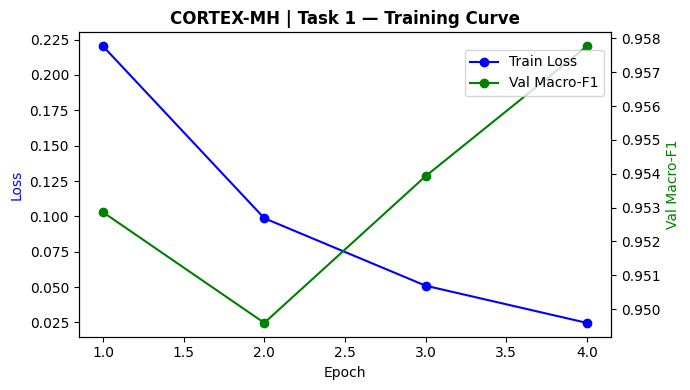

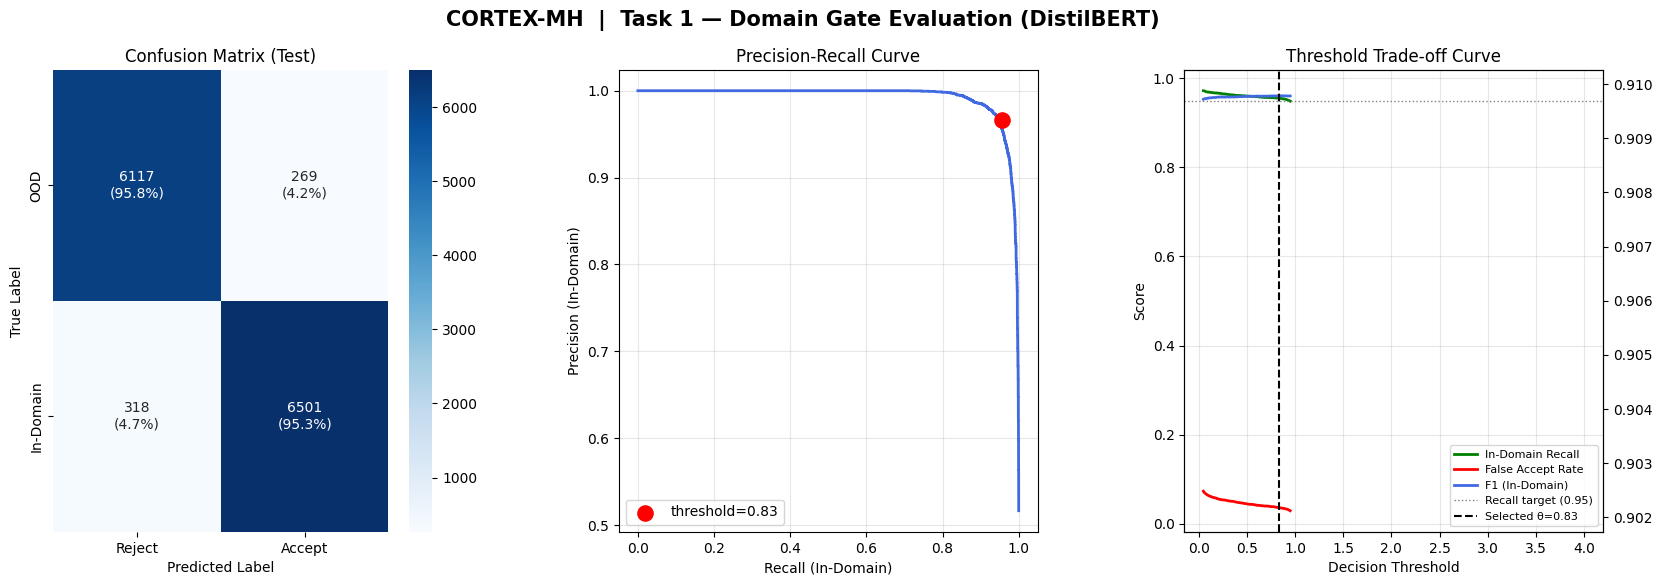

Plots saved.


In [9]:
# ── STEP 9: Test Evaluation + Plots ───────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

test_probs, test_labels = evaluate(model, test_loader)
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)

cm        = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
frr_test  = fn / (fn + tp)
far_test  = fp / (fp + tn)

print("=" * 60)
print("TASK 1 — TEST SET RESULTS (DistilBERT)")
print("=" * 60)
print(classification_report(test_labels, test_preds,
                             target_names=['OOD (Reject)', 'In-Domain (Accept)']))
print(f"False Reject Rate (missed real MH) : {frr_test:.4f}")
print(f"False Accept Rate (OOD slips in)   : {far_test:.4f}")

# ── Plots ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle('CORTEX-MH  |  Task 1 — Domain Gate Evaluation (DistilBERT)',
             fontsize=15, fontweight='bold')

# Plot 1: Confusion matrix
ax0 = fig.add_subplot(gs[0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{v}\n({cm_norm[i,j]:.1%})"
                   for j, v in enumerate(row)]
                  for i, row in enumerate(cm)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax0,
            xticklabels=['Reject', 'Accept'],
            yticklabels=['OOD', 'In-Domain'])
ax0.set_title('Confusion Matrix (Test)', fontsize=12)
ax0.set_ylabel('True Label')
ax0.set_xlabel('Predicted Label')

# Plot 2: Precision-Recall curve
ax1 = fig.add_subplot(gs[1])
p_c, r_c, _ = precision_recall_curve(test_labels, test_probs)
ax1.plot(r_c, p_c, 'royalblue', linewidth=2)
sel = thresh_df[thresh_df['threshold'] == BEST_THRESHOLD].iloc[0]
ax1.scatter(sel['recall_in_domain'], sel['precision_in_domain'],
            s=120, color='red', zorder=5,
            label=f'threshold={BEST_THRESHOLD:.2f}')
ax1.set_xlabel('Recall (In-Domain)')
ax1.set_ylabel('Precision (In-Domain)')
ax1.set_title('Precision-Recall Curve', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 3: Threshold trade-off
ax2 = fig.add_subplot(gs[2])
ax2.plot(thresh_df['threshold'], thresh_df['recall_in_domain'],
         'g-',        label='In-Domain Recall', linewidth=2)
ax2.plot(thresh_df['threshold'], thresh_df['false_accept_rate'],
         'r-',        label='False Accept Rate', linewidth=2)
ax2.plot(thresh_df['threshold'], thresh_df['f1_in_domain'],
         'royalblue', label='F1 (In-Domain)', linewidth=2)
ax2.axhline(TARGET_RECALL, color='gray', linestyle=':',  linewidth=1,
            label=f'Recall target ({TARGET_RECALL})')
ax2.axvline(BEST_THRESHOLD, color='k',  linestyle='--', linewidth=1.5,
            label=f'Selected θ={BEST_THRESHOLD:.2f}')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Threshold Trade-off Curve', fontsize=12)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 4: Training curve (inset in place of a 4th panel — added to plot 3)
ax2_twin = ax2.twinx()
ax2_twin.plot(range(1, EPOCHS + 1),
              [v * max(thresh_df['threshold']) / 1.0 for v in val_f1s],
              'k--', alpha=0.0)   # invisible — just reserves the axis

fig2, ax_train = plt.subplots(figsize=(7, 4))
ax_train.plot(range(1, EPOCHS + 1), train_losses, 'b-o', label='Train Loss')
ax_train2 = ax_train.twinx()
ax_train2.plot(range(1, EPOCHS + 1), val_f1s, 'g-o', label='Val Macro-F1')
ax_train.set_xlabel('Epoch')
ax_train.set_ylabel('Loss', color='b')
ax_train2.set_ylabel('Val Macro-F1', color='g')
ax_train.set_title('CORTEX-MH | Task 1 — Training Curve', fontweight='bold')
fig2.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig2.tight_layout()
fig2.savefig(SAVE_DIR / 't1_training_curve.png', dpi=150, bbox_inches='tight')

plt.figure(fig.number)
plt.savefig(SAVE_DIR / 't1_evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved.")

In [10]:
# ── STEP 10: Save Artifacts + Inference Function ──────────────
import pickle, json

# 1. Tokenizer
tokenizer.save_pretrained(SAVE_DIR / 't1_tokenizer')
print("Saved: t1_tokenizer/")

# 2. Threshold config
threshold_config = {
    'decision_threshold':         BEST_THRESHOLD,
    'target_in_domain_recall':    TARGET_RECALL,
    'val_recall_in_domain':       float(best_row['recall_in_domain']),
    'val_precision_in_domain':    float(best_row['precision_in_domain']),
    'val_f1_in_domain':           float(best_row['f1_in_domain']),
    'val_false_reject_rate':      float(best_row['false_reject_rate']),
    'val_false_accept_rate':      float(best_row['false_accept_rate'])
}
with open(SAVE_DIR / 'threshold.json', 'w') as f:
    json.dump(threshold_config, f, indent=2)
print("Saved: threshold.json")

# 3. Rejection taxonomy
rejection_taxonomy = {
    'rule_based': {
        'invalid':         'Empty or null input.',
        'too_short':       'Fewer than 5 words.',
        'url_only':        'Input is a URL with no accompanying text.',
        'symbol_only':     'Input contains only emoji / punctuation / symbols.',
        'high_repetition': 'Abnormally high character repetition ratio (>0.45).',
        'non_english':     'Detected as non-English by langdetect.'
    },
    'model_based': {
        'ood_classifier': (f'DistilBERT in-domain probability below '
                           f'decision threshold ({BEST_THRESHOLD}).')
    }
}
with open(SAVE_DIR / 'rejection_taxonomy.json', 'w') as f:
    json.dump(rejection_taxonomy, f, indent=2)
print("Saved: rejection_taxonomy.json")

# 4. Evaluation report
test_clf_report = classification_report(
    test_labels, test_preds,
    target_names=['OOD', 'In-Domain'],
    output_dict=True
)
eval_report = {
    'task':              'Task 1 — Domain Gate / OOD Classifier',
    'model':             'DistilBERT (distilbert-base-uncased) fine-tuned binary classifier',
    'in_domain_dataset': 'ourafla/Mental-Health_Text-Classification_Dataset',
    'ood_dataset':       'google-research-datasets/go_emotions (hard negatives)',
    'training': {
        'epochs':       EPOCHS,
        'lr':           LR,
        'batch_size':   BATCH_SIZE,
        'max_length':   MAX_LENGTH,
        'best_epoch':   best_epoch,
        'best_val_f1':  best_val_f1
    },
    'data': {
        'in_domain_raw':               len(texts_in),
        'ood_raw':                     len(ood_texts),
        'in_domain_clean':             len(in_clean_texts),
        'ood_clean':                   len(ood_clean_texts),
        'train':                       len(X_train),
        'val':                         len(X_val),
        'test':                        len(X_test),
        'in_domain_rejected_by_rules': len(in_rejected),
        'ood_rejected_by_rules':       len(ood_rejected)
    },
    'sanitization_rejection_reasons': {
        'in_domain': dict(in_rej_counts),
        'ood':       dict(ood_rej_counts)
    },
    'threshold_config':               threshold_config,
    'test_classification_report':     test_clf_report,
    'test_confusion_matrix':          cm.tolist(),
    'test_false_reject_rate':         float(frr_test),
    'test_false_accept_rate':         float(far_test)
}
with open(SAVE_DIR / 't1_evaluation_report.json', 'w') as f:
    json.dump(eval_report, f, indent=2)
print("Saved: t1_evaluation_report.json")

# 5. Threshold curve
thresh_df.to_csv(SAVE_DIR / 't1_threshold_curve.csv', index=False)
print("Saved: t1_threshold_curve.csv")

# ── Inference function ────────────────────────────────────────
def domain_gate(
    text: str,
    model=model,
    tokenizer=tokenizer,
    threshold: float = BEST_THRESHOLD,
    device=DEVICE
) -> dict:
    """
    Gate a single raw text input.

    Returns
    -------
    dict:
        accept_reject     : int   — 1 (accept) | 0 (reject)
        domain_confidence : float — P(in-domain) from DistilBERT, or 0.0 for rule rejects
        rejection_reason  : str | None
    """
    # Stage 1: Rule-based pre-filter
    rule_reason = sanitize_text(text)
    if rule_reason is not None:
        return {'accept_reject': 0, 'domain_confidence': 0.0,
                'rejection_reason': rule_reason}

    # Stage 2: DistilBERT classifier
    model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    with torch.no_grad():
        logits = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        ).logits
        prob = torch.softmax(logits, dim=-1)[0, 1].item()

    if prob >= threshold:
        return {'accept_reject': 1, 'domain_confidence': prob,
                'rejection_reason': None}
    else:
        return {'accept_reject': 0, 'domain_confidence': prob,
                'rejection_reason': 'ood_classifier'}


# ── Demo ──────────────────────────────────────────────────────
DEMO_INPUTS = [
    "I've been feeling so hopeless lately, I don't see a reason to keep going.",
    "I'm so sad my team lost the championship game last night.",
    "lol",
    "https://reddit.com/r/depression/comments/xyz",
    "I have been struggling with severe depression and anxiety for months now.",
    "The quarterly earnings report shows a 12% increase in YoY revenue.",
    "I feel so nervous and scared, I don't know how to handle this anymore.",
    "Scientists discover new exoplanet orbiting a distant star in the Milky Way.",
    "I can't stop thinking about ending it. Every day feels unbearable.",
    "I'm so angry and frustrated, this job is going to give me a breakdown.",
]

print("\nDOMAIN GATE — INFERENCE DEMO (DistilBERT)")
print("=" * 72)
for text in DEMO_INPUTS:
    r = domain_gate(text)
    status = "✓  ACCEPT" if r['accept_reject'] == 1 else "✗  REJECT"
    print(f"\n{status} | conf={r['domain_confidence']:.3f} | reason={r['rejection_reason']}")
    print(f"   '{text[:80]}{'...' if len(text) > 80 else ''}'")

print("\nAll Task 1 artifacts saved to CORTEX/T1/")



# # ── STEP 9: Save Artifacts ────────────────────────────────────

# # 1. Model
# with open(SAVE_DIR / 'domain_gate_model.pkl', 'wb') as f:
#     pickle.dump(gate_pipeline, f)
# print("Saved: domain_gate_model.pkl")

# # 2. Threshold config
# threshold_config = {
#     'decision_threshold':    BEST_THRESHOLD,
#     'target_in_domain_recall': TARGET_RECALL,
#     'val_recall_in_domain':   float(best_row['recall_in_domain']),
#     'val_precision_in_domain':float(best_row['precision_in_domain']),
#     'val_f1_in_domain':       float(best_row['f1_in_domain']),
#     'val_false_reject_rate':  float(best_row['false_reject_rate']),
#     'val_false_accept_rate':  float(best_row['false_accept_rate'])
# }
# with open(SAVE_DIR / 'threshold.json', 'w') as f:
#     json.dump(threshold_config, f, indent=2)
# print("Saved: threshold.json")

# # 3. Rejection taxonomy
# rejection_taxonomy = {
#     'rule_based': {
#         'invalid':         'Empty or null input.',
#         'too_short':       'Fewer than 5 words.',
#         'url_only':        'Input is a URL with no accompanying text.',
#         'symbol_only':     'Input contains only emoji / punctuation / symbols.',
#         'high_repetition': 'Abnormally high character repetition ratio (>0.45).',
#         'non_english':     'Input detected as non-English by langdetect.'
#     },
#     'model_based': {
#         'ood_classifier':  (f'TF-IDF+LR in-domain probability below '
#                             f'decision threshold ({BEST_THRESHOLD}).')
#     }
# }
# with open(SAVE_DIR / 'rejection_taxonomy.json', 'w') as f:
#     json.dump(rejection_taxonomy, f, indent=2)
# print("Saved: rejection_taxonomy.json")

# # 4. Full evaluation report
# test_clf_report = classification_report(
#     y_test_arr, test_preds,
#     target_names=['OOD', 'In-Domain'],
#     output_dict=True
# )
# eval_report = {
#     'task':              'Task 1 — Domain Gate / OOD Classifier',
#     'model':             'TF-IDF (word 1-2gram + char 3-5gram) + Logistic Regression',
#     'in_domain_dataset': 'ourafla/Mental-Health_Text-Classification_Dataset',
#     'ood_dataset':       'Salesforce/wikitext wikitext-103-v1',
#     'data': {
#         'in_domain_raw':      len(texts_in),
#         'ood_raw':            len(wiki_texts),
#         'in_domain_clean':    len(in_clean_texts),
#         'ood_clean':          len(ood_clean_texts),
#         'train':              len(X_train),
#         'val':                len(X_val),
#         'test':               len(X_test),
#         'in_domain_rejected_by_rules': len(in_rejected),
#         'ood_rejected_by_rules':       len(ood_rejected)
#     },
#     'sanitization_rejection_reasons': {
#         'in_domain': dict(in_rej_counts),
#         'ood':       dict(ood_rej_counts)
#     },
#     'threshold_config':       threshold_config,
#     'test_classification_report': test_clf_report,
#     'test_confusion_matrix':  cm.tolist(),
#     'test_false_reject_rate': float(frr_test),
#     'test_false_accept_rate': float(far_test)
# }
# with open(SAVE_DIR / 't1_evaluation_report.json', 'w') as f:
#     json.dump(eval_report, f, indent=2)
# print("Saved: t1_evaluation_report.json")

# # 5. Threshold curve
# thresh_df.to_csv(SAVE_DIR / 't1_threshold_curve.csv', index=False)
# print("Saved: t1_threshold_curve.csv")

# print("\nAll Task 1 artifacts saved to CORTEX/T1/")

Saved: t1_tokenizer/
Saved: threshold.json
Saved: rejection_taxonomy.json
Saved: t1_evaluation_report.json
Saved: t1_threshold_curve.csv

DOMAIN GATE — INFERENCE DEMO (DistilBERT)

✓  ACCEPT | conf=0.998 | reason=None
   'I've been feeling so hopeless lately, I don't see a reason to keep going.'

✓  ACCEPT | conf=0.948 | reason=None
   'I'm so sad my team lost the championship game last night.'

✗  REJECT | conf=0.000 | reason=url_only
   'lol'

✗  REJECT | conf=0.000 | reason=url_only
   'https://reddit.com/r/depression/comments/xyz'

✗  REJECT | conf=0.235 | reason=ood_classifier
   'I have been struggling with severe depression and anxiety for months now.'

✗  REJECT | conf=0.026 | reason=ood_classifier
   'The quarterly earnings report shows a 12% increase in YoY revenue.'

✓  ACCEPT | conf=0.997 | reason=None
   'I feel so nervous and scared, I don't know how to handle this anymore.'

✗  REJECT | conf=0.804 | reason=ood_classifier
   'Scientists discover new exoplanet orbiting a d